In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

In [10]:
data = pd.read_csv("winequality-red.csv")

In [11]:
data['quality_binary'] = data['quality'].apply(lambda q: 1 if q >= 7 else 0)


In [12]:
X = data.drop(['quality', 'quality_binary'], axis=1)
y = data['quality_binary']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [15]:
y_pred = model.predict(X_test)

In [16]:
cm = confusion_matrix(y_test, y_pred)
TP = cm[1, 1]
FP = cm[0, 1]
TN = cm[0, 0]
FN = cm[1, 0]

In [17]:
accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

In [18]:
print("Confusion Matrix:")
print(cm)
print(f"\nTrue Positives (TP): {TP}")
print(f"False Positives (FP): {FP}")
print(f"True Negatives (TN): {TN}")
print(f"False Negatives (FN): {FN}")
print(f"\nAccuracy: {accuracy:.4f}")
print(f"Error Rate: {error_rate:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Confusion Matrix:
[[264   9]
 [ 36  11]]

True Positives (TP): 11
False Positives (FP): 9
True Negatives (TN): 264
False Negatives (FN): 36

Accuracy: 0.8594
Error Rate: 0.1406
Precision: 0.5500
Recall: 0.2340


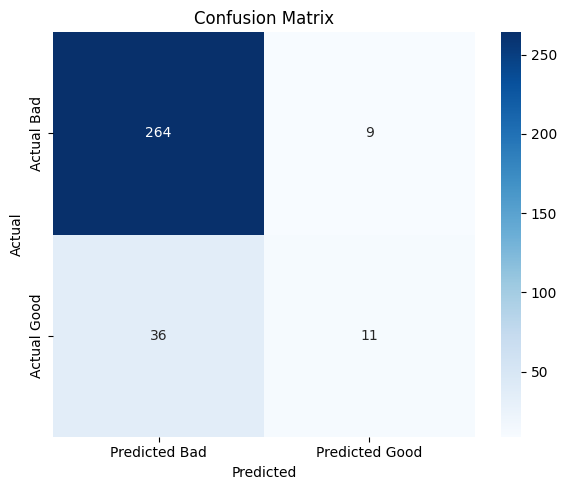

In [19]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Predicted Bad", "Predicted Good"], yticklabels=["Actual Bad", "Actual Good"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

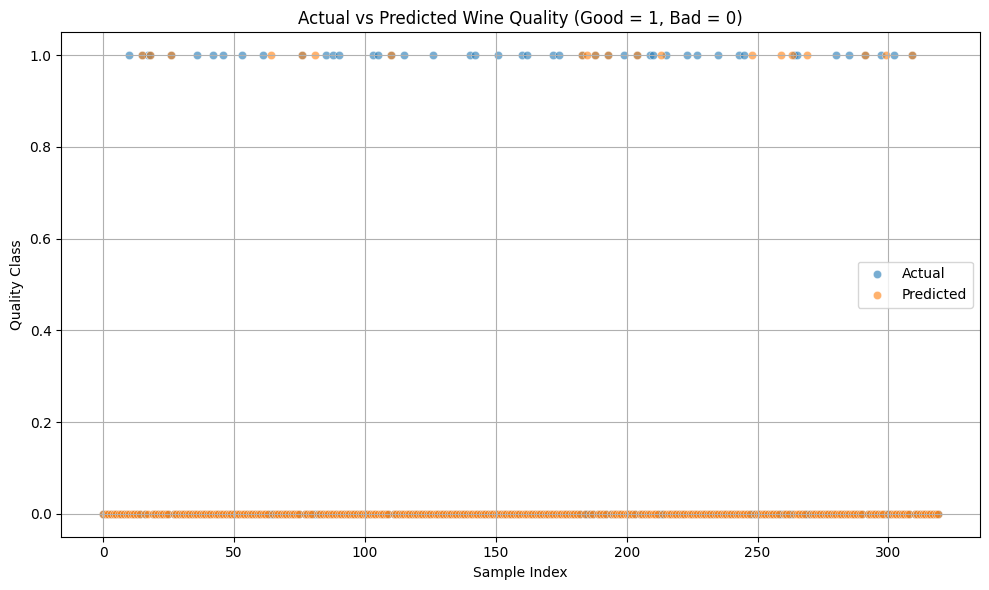

In [24]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=np.arange(len(y_test)), y=y_test.values, label='Actual', alpha=0.6)
sns.scatterplot(x=np.arange(len(y_pred)), y=y_pred, label='Predicted', alpha=0.6)
plt.title("Actual vs Predicted Wine Quality (Good = 1, Bad = 0)")
plt.xlabel("Sample Index")
plt.ylabel("Quality Class")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()